In [1]:
from reflect.components.flow_world_model.dynamic_model import DynamicFlowModel, DynamicAttentionalFlowModel
from reflect.components.flow_world_model.world_model_actor import WorldModelActor
from reflect.components.flow_world_model.world_model import WorldModel
from reflect.data.loader import EnvDataLoader
from reflect.components.models.actor import Actor
from reflect.components.trainers.value.value_trainer import ValueGradTrainer
from reflect.components.trainers.value.critic import ValueCritic

from tqdm import tqdm
from livelossplot import PlotLosses
import gymnasium as gym
from dataclasses import asdict
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.optim as optim
import numpy as np
import torch.nn as nn
from torch.distributions import Normal


/Users/alexathorne/development/personal/world-model-rl/venv/lib/python3.10/site-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment InvertedPendulum-v4 is out of date. You should consider upgrading to version `v5`.
  logger.deprecation(


In [2]:
env = gym.make('Pendulum-v1', render_mode='rgb_array')

state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
device='cpu'


In [3]:
actor = Actor(
    input_dim=state_dim,
    output_dim=action_dim,
    bound=env.action_space.high,
).to(device)

critic = ValueCritic(
    state_dim=state_dim,
).to(device)

trainer = ValueGradTrainer(
    actor=actor,
    critic=critic,
    actor_lr=0.001,
    critic_lr=0.001,
)
trainer.to(device)

In [4]:

world_model_actor = WorldModelActor(
    actor=actor,
)

env_data_loader = EnvDataLoader(
    num_time_steps=3,
    rollout_length=200,
    num_runs=1000,
    noise_size=0.3,
    state_shape=(state_dim,),
    policy=world_model_actor,
    env=env,
    use_imgs_as_states=False,
)


In [5]:
for _ in tqdm(range(10)):
    env_data_loader.perform_rollout()

  0%|          | 0/10 [00:00<?, ?it/s]

100%|██████████| 10/10 [00:03<00:00,  2.52it/s]


In [6]:
state_dim = 3+1+1
action_dim = 1

# dynamic_model = DynamicFlowModel(
#     input_dim=state_dim,
#     conditioning_dim=3*(state_dim + action_dim),
#     output_dim=state_dim,
#     time_embed_dim=16,
#     hidden_dim=128,
#     depth=2,
#     use_layer_norm=True,
#     num_positions=3,
# )

# world_model = WorldModel(
#     dynamic_model=dynamic_model,
#     observation_dim=state_dim-2,
#     action_dim=action_dim,
#     environment_action_bound=env.action_space.high,
# )

dynamic_model = DynamicAttentionalFlowModel(
    input_dim=state_dim,
    conditioning_dim=state_dim + action_dim,
    output_dim=state_dim,
    num_heads=4,
    hidden_dim=256,
    depth=2,
    use_layer_norm=True,
    num_positions=3,
)

world_model = WorldModel(
    dynamic_model=dynamic_model,
    observation_dim=state_dim-2,
    action_dim=action_dim,
    environment_action_bound=env.action_space.high,
)


In [7]:
plot_losses = PlotLosses(
  groups={
    'flow_loss': ['flow_loss'],
    'rel_err': ['rel_err'],
    'value_loss': ['value_loss'],
    'value_grad_norm': ['value_grad_norm'],
    'actor_loss': ['actor_loss'],
    'actor_grad_norm': ['actor_grad_norm'],
    'reward': ['reward'],
    'imagined_reward': ['imagined_reward'],
  },
)

In [8]:
def test_actor(actor, env, render=False):
    o, *_ = env.reset()
    total_reward = 0
    images = []
    for _ in range(1000):
        a = actor(torch.tensor(o), deterministic=True)
        o, r, d, *_ = env.step(a.detach())
        if render:
            images.append(env.render())
        total_reward += r
        if d:
            break
    if render:
        return total_reward, images
    else:
        return total_reward

test_actor(actor, env)


tensor(-5070.2153)

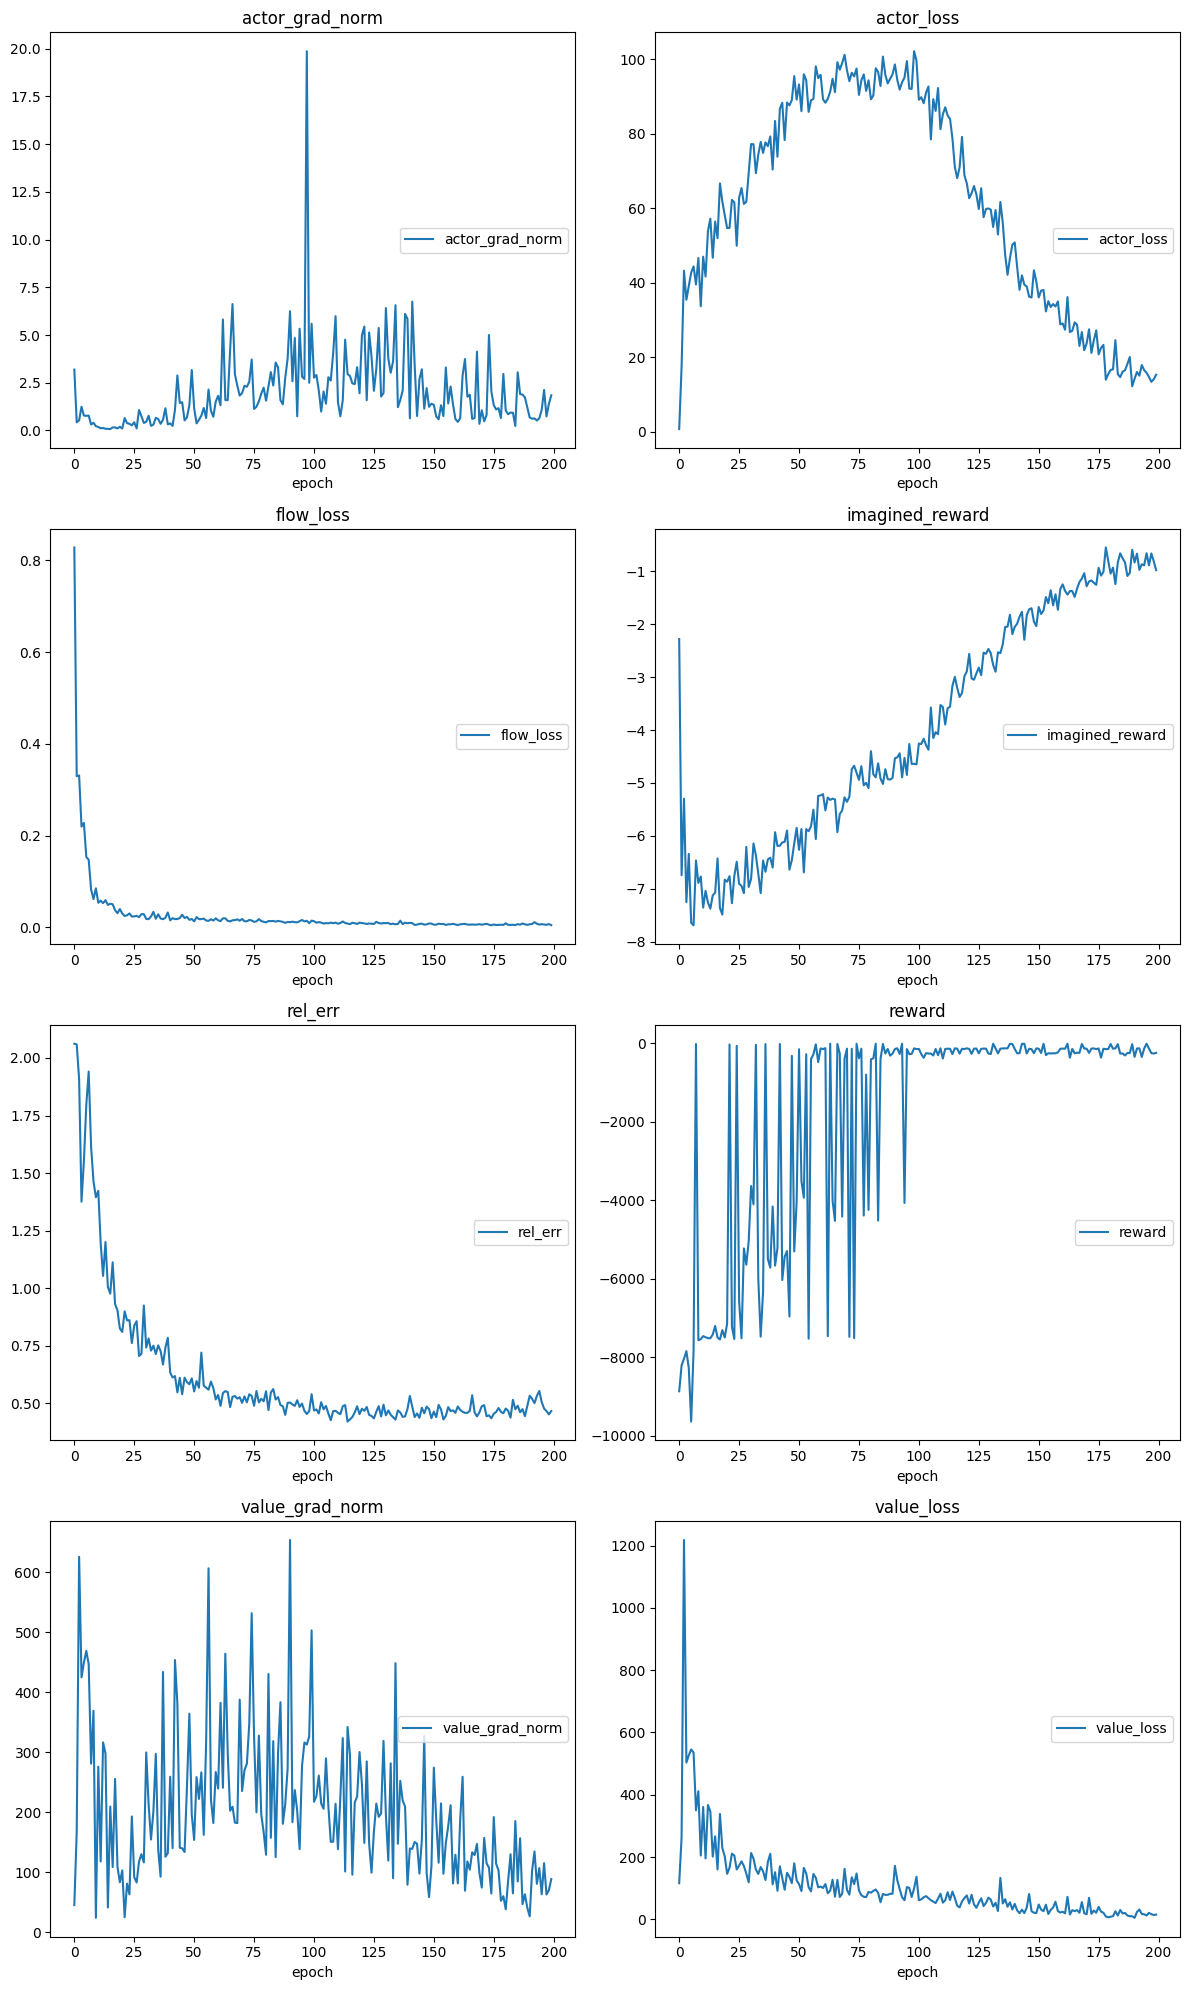

actor_grad_norm
	actor_grad_norm  	 (min:    0.072, max:   19.869, cur:    1.841)
actor_loss
	actor_loss       	 (min:    0.688, max:  102.149, cur:   15.288)
flow_loss
	flow_loss        	 (min:    0.004, max:    0.828, cur:    0.005)
imagined_reward
	imagined_reward  	 (min:   -7.694, max:   -0.547, cur:   -0.976)
rel_err
	rel_err          	 (min:    0.420, max:    2.062, cur:    0.466)
reward
	reward           	 (min: -9636.943, max:   -6.037, cur: -239.255)
value_grad_norm
	value_grad_norm  	 (min:   24.288, max:  653.818, cur:   88.901)
value_loss
	value_loss       	 (min:    4.919, max: 1218.120, cur:   15.294)


In [9]:

update_every = 10

for epoch in range(2_000):
    env_data_loader.perform_rollout()
    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=4
    )
    world_model_losses = world_model.update(o, a, r, d)

    _, _, o, a, r, d = env_data_loader.sample(
        batch_size=256,
        num_time_steps=3
    )

    o.requires_grad = True
    a.requires_grad = True
    r.requires_grad = True
    d = d.to(torch.float32)
    d.requires_grad = True

    img_o, img_a, img_r, img_d = world_model.imagine_rollout(
        o, a, r, d,
        actor,
        num_timesteps=10,
        num_flow_steps=1,
        noise_scale=0.0
    )

    trainer_history = trainer.update(
        state_samples=img_o,
        reward_samples=img_r,
        done_samples=img_d
    )

    trainer_history = asdict(trainer_history)
    world_model_losses = asdict(world_model_losses)
    if epoch % update_every == 0:        
        plot_losses.update(
            {
                **world_model_losses,
                **trainer_history,
                'reward': test_actor(actor, env),
                'imagined_reward': img_r.detach().sum(-1).mean()
            }
        )
        plot_losses.send()
        total_loss = 0 
        total_rel_err = 0


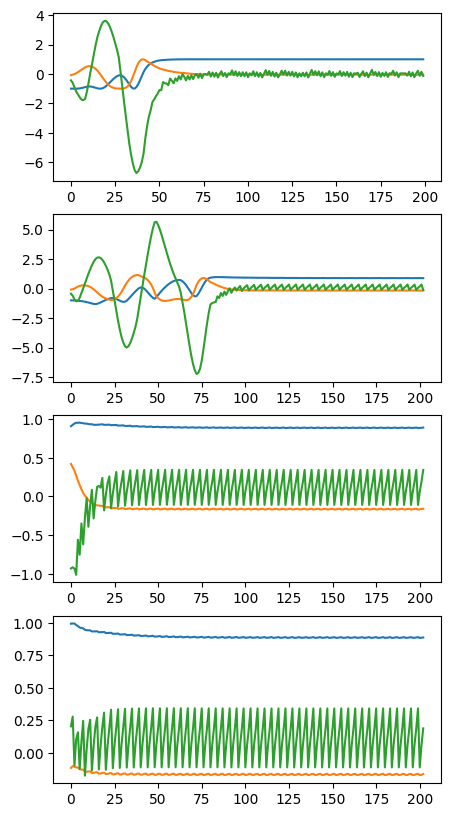

In [13]:
import matplotlib.pyplot as plt
import random
batch_size=3
traj_i = random.randint(0, env_data_loader.num_runs - 1 - batch_size)

o = env_data_loader.state_buffer[traj_i:traj_i+batch_size]
a = env_data_loader.action_buffer[traj_i:traj_i+batch_size]
r = env_data_loader.reward_buffer[traj_i:traj_i+batch_size][:, :, None]
d = env_data_loader.done_buffer[traj_i:traj_i+batch_size][:, :, None]

img_o, img_a, img_r, img_d = world_model.imagine_rollout(
    o[:, :3], a[:, :3], r[:, :3], d[:, :3],
    actor,
    num_timesteps=200,
    num_flow_steps=10,
    noise_scale=0.0
)

img_o = img_o.detach()
fig, axs = plt.subplots(nrows=batch_size+1, figsize=(5, 10))
axs[0].plot(o[0, :, 0])
axs[0].plot(o[0, :, 1])
axs[0].plot(o[0, :, 2])
for i in range(1, batch_size + 1):
    axs[i].plot(img_o[i-1, :, 0])
    axs[i].plot(img_o[i-1, :, 1])
    axs[i].plot(img_o[i-1, :, 2])
plt.show()

In [14]:
reward, images = test_actor(actor, env, render=True)

In [ ]:
reward, images = test_actor(actor, env, render=True)

from matplotlib import animation
from IPython.display import HTML
import matplotlib.pyplot as plt

# Create figure and axis
fig, ax = plt.subplots(figsize=(6, 6))
ax.axis('off')

# Display first frame
im = ax.imshow(images[0])

# Animation update function
def update(frame):
    im.set_array(images[frame])
    return [im]

# Create animation
anim = animation.FuncAnimation(
    fig, 
    update, 
    frames=len(images),
    interval=20,  # milliseconds between frames (50 FPS)
    blit=True
)

# Display in notebook
plt.close()  # Prevent static image from showing
HTML(anim.to_html5_video())

: 